# 0. Imports

In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

from src.features import FeatureSet, SIFT
from src.visualization import (
    plot_features,
    plot_keypoint_comparison,
    plot_sift_descriptor,
    plot_keypoint_distribution,
)
from src.anms import anms

In [ ]:
campus_0 = cv.imread("inputs/udesa_0.jpg")
campus_1 = cv.imread("inputs/udesa_1.jpg")
campus_2 = cv.imread("inputs/udesa_2.jpg")

cuadro_0 = cv.imread("inputs/cuadro_0.jpg")
cuadro_1 = cv.imread("inputs/cuadro_1.jpg")
cuadro_2 = cv.imread("inputs/cuadro_2.jpg")

campus_images = [campus_0, campus_1, campus_2]
cuadro_images = [cuadro_0, cuadro_1, cuadro_2]

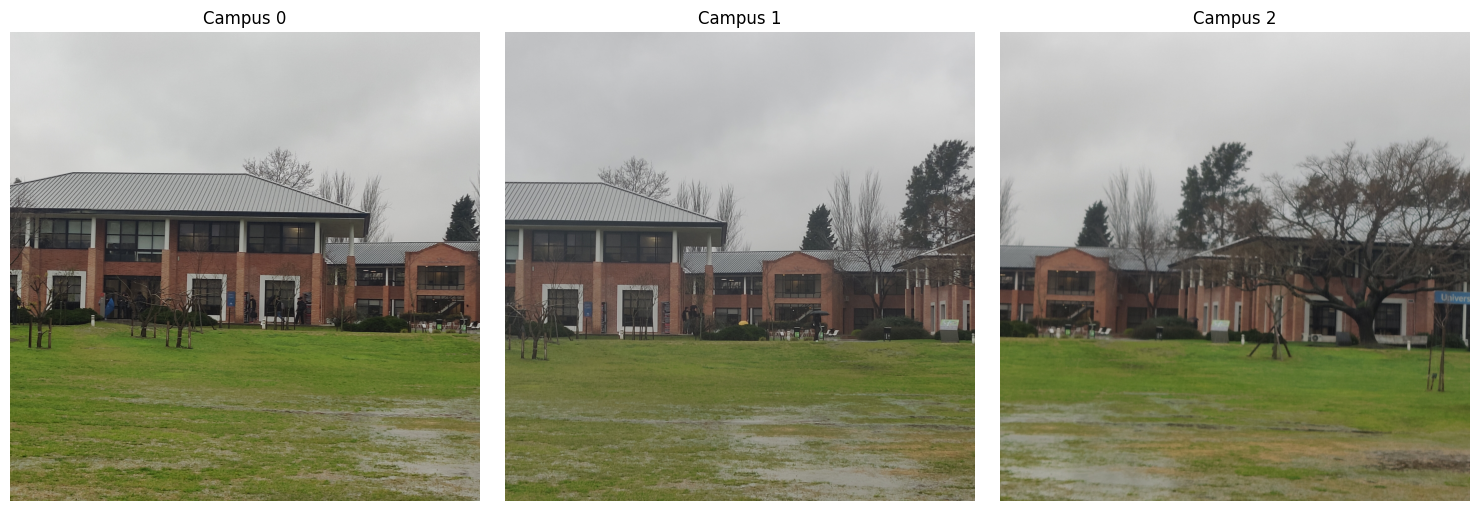

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, image) in enumerate(zip(axes, campus_images)):
    ax.imshow(image[:, :, ::-1], cmap="gray")
    ax.set_title(f"Campus {i}")
    ax.axis("off")

plt.tight_layout()

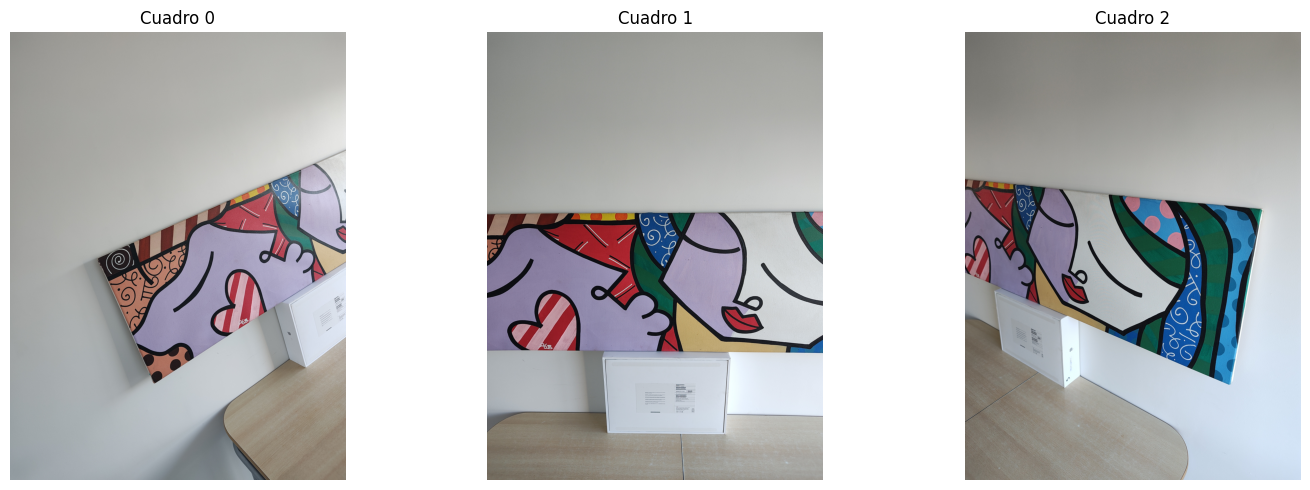

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, image) in enumerate(zip(axes, cuadro_images)):
    ax.imshow(image[:, :, ::-1], cmap="gray")
    ax.set_title(f"Cuadro {i}")
    ax.axis("off")

plt.tight_layout()

# 1. Preprocesamiento

In [46]:
sift = SIFT()

campus_keypoints = [
    sift.detect(image)
    for image in campus_images
]

for i, keypoints in enumerate(campus_keypoints):
    print(f"Campus {i}: {len(keypoints)} keypoints")

Campus 0: 22105 keypoints
Campus 1: 14851 keypoints
Campus 2: 5364 keypoints


In [47]:
MAX_KEYPOINTS = 2000
LOCAL_RADIUS = 10

campus_keypoints_anms = [
    anms(keypoints, MAX_KEYPOINTS, LOCAL_RADIUS)
    for keypoints in campus_keypoints
]

for i, keypoints in enumerate(campus_keypoints_anms):
    print(f"Campus {i}: {len(keypoints)} keypoints")

Campus 0: 2000 keypoints
Campus 1: 2000 keypoints
Campus 2: 2000 keypoints


In [48]:
campus_features = [
    sift.describe(image, keypoints)
    for image, keypoints in zip(
        campus_images,
        campus_keypoints_anms,
    )
]

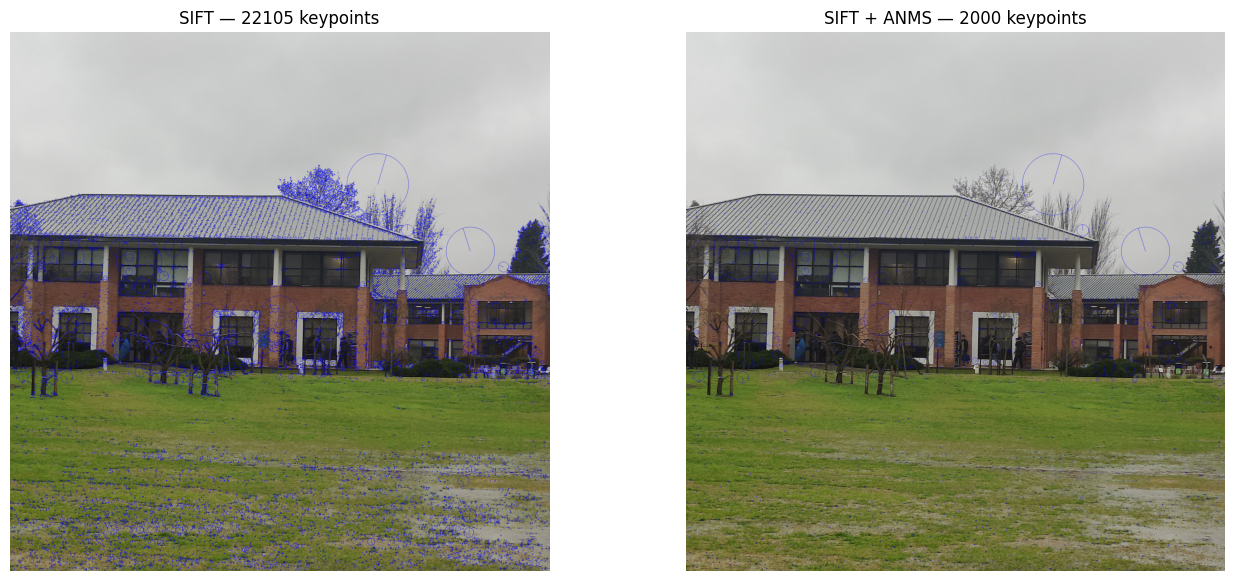

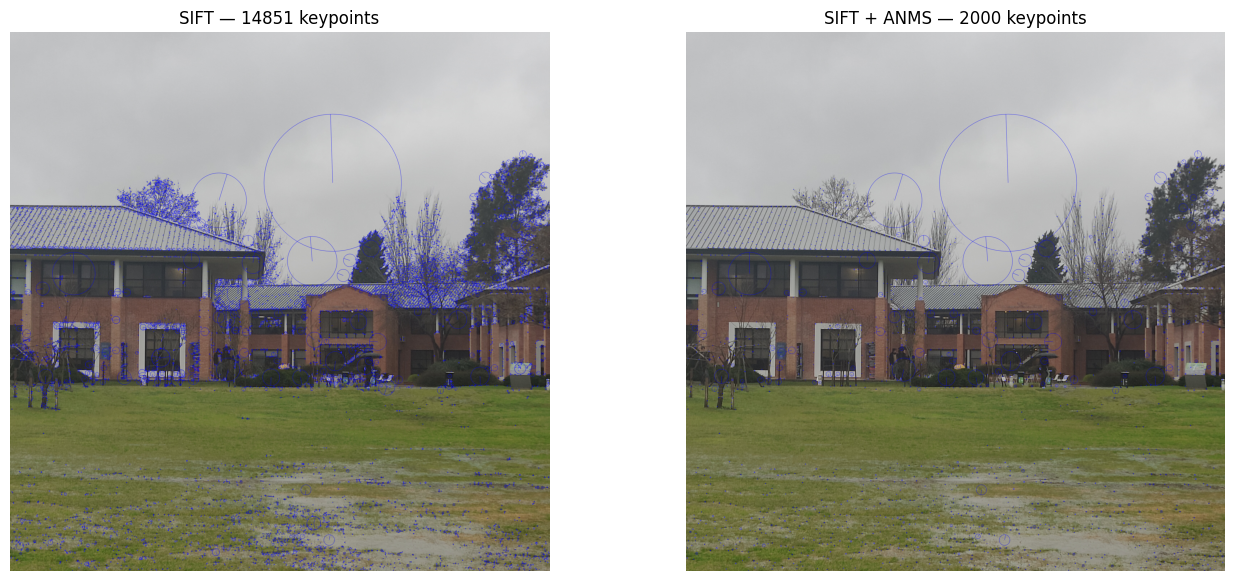

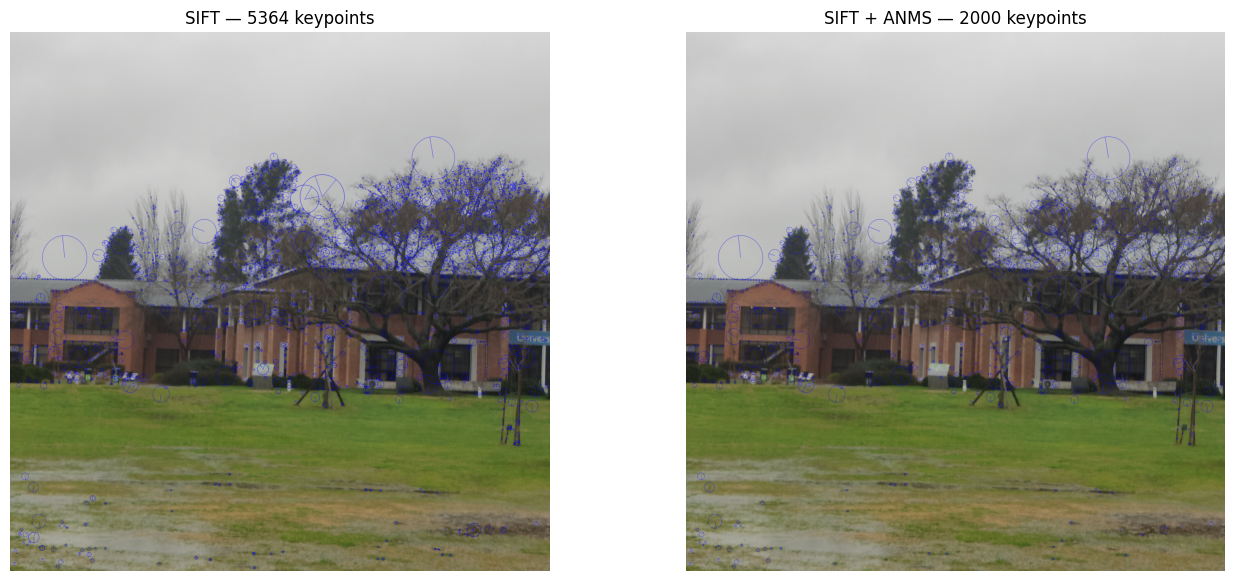

In [58]:
for i, image in enumerate(campus_images):
    plot_keypoint_comparison(
        image,
        campus_keypoints[i],
        campus_keypoints_anms[i],
        titles=("SIFT", "SIFT + ANMS"),
    )

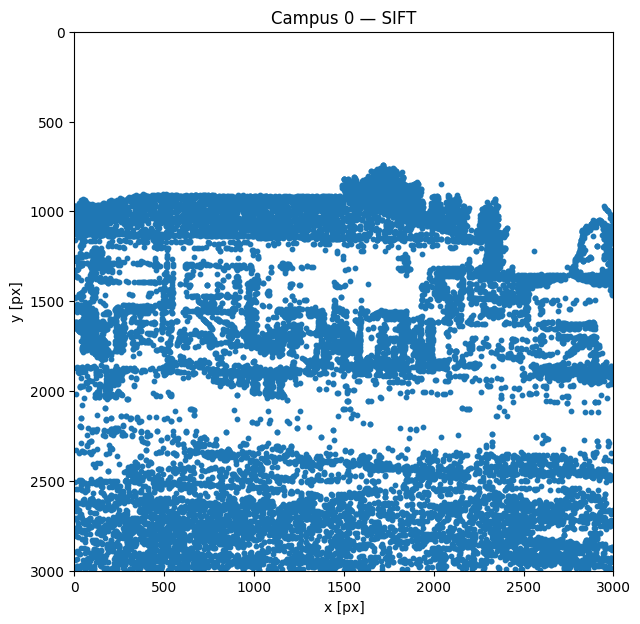

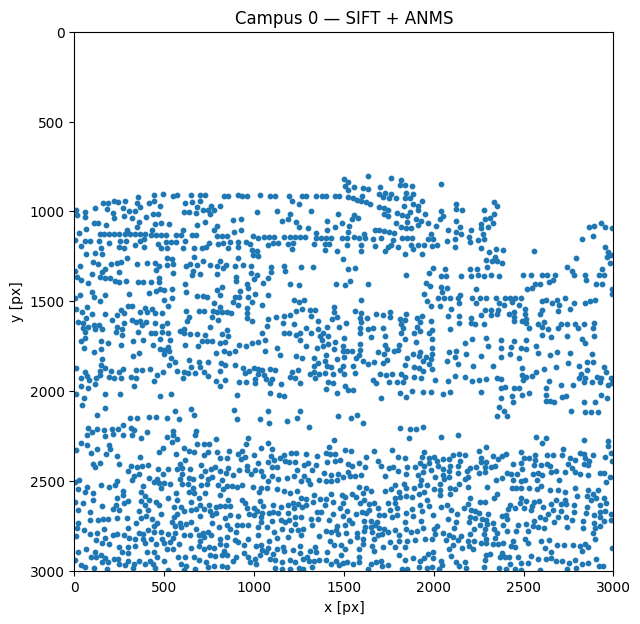

In [59]:
plot_keypoint_distribution(
    campus_0,
    campus_keypoints[0],
    title="Campus 0 — SIFT",
)

plot_keypoint_distribution(
    campus_0,
    campus_keypoints_anms[0],
    title="Campus 0 — SIFT + ANMS",
)

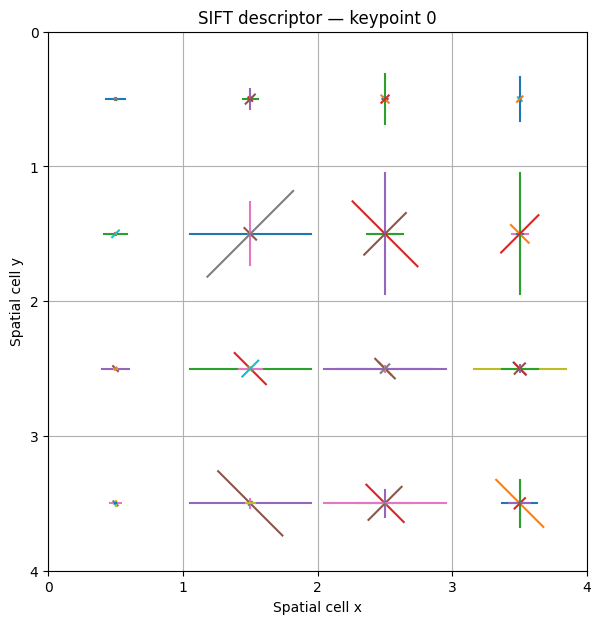

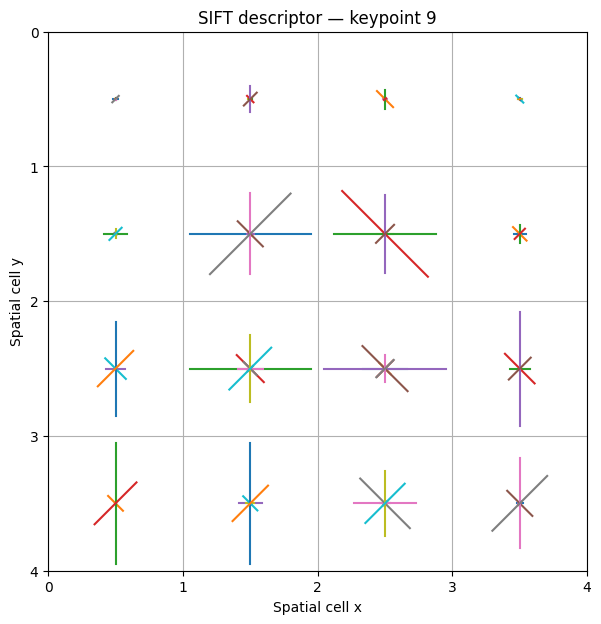

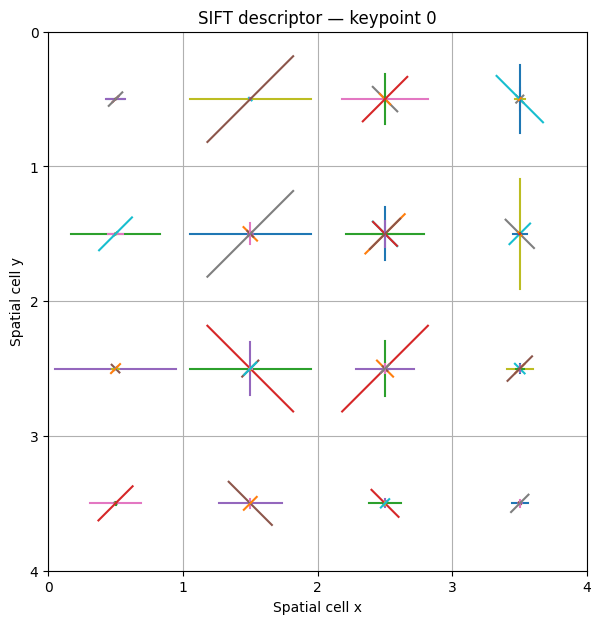

In [64]:
for i, features in enumerate(campus_features):
    index = np.argmax([
        kp.response
        for kp in features.keypoints
    ])

    plot_sift_descriptor(
        features,
        index,
    )

# 2. Descriptor matching